# Hot Jupiter vs Non–Hot Jupiter with SVM on NASA Exoplanet Archive data

This notebook is designed for **master students** to explore **Support Vector Machines (SVMs)** on real exoplanet data from the **NASA Exoplanet Archive**.

## Scientific goal

We define an **operational Hot Jupiter label** as

$$
\mathrm{Hot\ Jupiter} =
\begin{cases}
1, & \text{if } P < 10\ \text{days and } R_p > 8R_\oplus \\
0, & \text{otherwise}
\end{cases}
$$

where:

- $P$ is the orbital period (`pl_orbper`)
- $R_p$ is the planetary radius (`pl_rade`)

This definition is convenient because **radius is often available more broadly than precise dynamical mass**.

## Methodological warning

Because the label is built **directly** from `pl_orbper` and `pl_rade`, any classifier trained with those same features is partly learning the **definition** of the label.

That is not a flaw for teaching. It is actually useful because students can learn:

1. how an SVM behaves,
2. how coefficients are interpreted,
3. what **label leakage / definition leakage** means in supervised learning.

## Notebook structure

We will run two experiments:

### Experiment A — definition-aware classification
Use a broad feature set **including** `pl_orbper` and `pl_rade`.

This shows how the SVM reconstructs the operational label.

### Experiment B — more scientific / less trivial classification
Remove the defining features:

- `pl_orbper`
- `pl_rade`

and ask whether other features such as:

- semi-major axis,
- equilibrium temperature,
- stellar properties,

can still help predict the class indirectly.

At the end, students can compare both cases.

In [3]:
import io
import warnings
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)

## 1. Download data from the NASA Exoplanet Archive

We query the `pscomppars` table through the TAP service.

`pscomppars` is a good teaching table because it provides one composite row per confirmed planet and is convenient for exploratory statistical work.

In [4]:
TAP_URL = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync"

query = '''
SELECT
    pl_name,
    hostname,
    discoverymethod,
    disc_year,
    pl_orbper,
    pl_rade,
    pl_bmasse,
    pl_orbeccen,
    pl_orbsmax,
    pl_eqt,
    st_teff,
    st_rad,
    st_mass,
    st_met,
    st_logg,
    sy_dist,
    sy_vmag
FROM pscomppars
'''

response = requests.get(
    TAP_URL,
    params={"query": query, "format": "csv"},
    timeout=120
)

if not response.ok:
    print("Server response:")
    print(response.text[:1200])

response.raise_for_status()
exo = pd.read_csv(io.StringIO(response.text))
print("Downloaded shape:", exo.shape)
exo.head()

Downloaded shape: (6153, 17)


,pl_name,hostname,discoverymethod,disc_year,pl_orbper,pl_rade,pl_bmasse,pl_orbeccen,pl_orbsmax,pl_eqt,st_teff,st_rad,st_mass,st_met,st_logg,sy_dist,sy_vmag
0,Kepler-1167 b,Kepler-1167,Transit,2016.0,1.003934,1.710000,3.570,0.0,0.01750,1419.0,4971.0,0.750,0.790,-0.05,4.600,820.905,16.0470
1,Kepler-1740 b,Kepler-1740,Transit,2021.0,8.172400,3.323214,11.000,0.0,0.07790,858.0,5705.0,0.905,0.943,-0.06,4.499,1061.770,15.4540
2,Kepler-1581 b,Kepler-1581,Transit,2016.0,6.283855,0.800000,0.437,0.0,0.06865,1108.0,6022.0,1.230,1.120,0.07,4.310,493.175,12.4420
3,Kepler-644 b,Kepler-644,Transit,2016.0,3.173917,3.150000,10.100,0.0,0.04641,1655.0,6747.0,1.810,1.490,0.08,4.090,1318.050,14.0310
4,Kepler-1752 b,Kepler-1752,Transit,2021.0,56.358501,4.540605,18.700,0.0,0.26980,419.0,5446.0,0.821,0.824,-0.20,4.525,962.888,16.0249


## 2. Build the Hot Jupiter target

We define a Hot Jupiter using the operational rule

- `pl_orbper < 10`
- `pl_rade > 8`

In [5]:
exo = exo.copy()

exo["hot_jupiter"] = (
    (exo["pl_orbper"] < 10) &
    (exo["pl_rade"] > 8)
).astype(int)

exo["hot_jupiter"].value_counts(dropna=False)

hot_jupiter
0    5414
1     739
Name: count, dtype: int64

## 3. Quick data inspection

In [6]:
summary = pd.DataFrame({
    "missing_fraction": exo.isna().mean().sort_values(ascending=False),
    "dtype": exo.dtypes.astype(str)
})
summary

,missing_fraction,dtype
disc_year,0.000163,float64
discoverymethod,0.000000,object
hostname,0.000000,object
hot_jupiter,0.000000,int64
pl_bmasse,0.005038,float64
pl_eqt,0.254022,float64
pl_name,0.000000,object
pl_orbeccen,0.152446,float64
pl_orbper,0.054282,float64
pl_orbsmax,0.051357,float64


Class fractions:


hot_jupiter
0    0.879896
1    0.120104
Name: fraction, dtype: float64

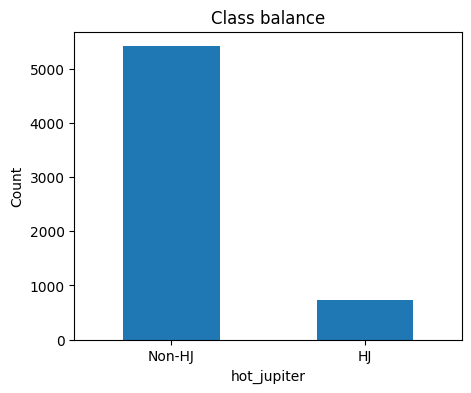

In [7]:
class_balance = exo["hot_jupiter"].value_counts(normalize=True).rename("fraction")
print("Class fractions:")
display(class_balance)

plt.figure(figsize=(5,4))
exo["hot_jupiter"].value_counts().sort_index().plot(kind="bar")
plt.xticks([0,1], ["Non-HJ", "HJ"], rotation=0)
plt.ylabel("Count")
plt.title("Class balance")
plt.show()

## 4. Choose features

We keep a compact set of numerical astrophysical features.

In [8]:
base_features = [
    "pl_orbper",
    "pl_rade",
    "pl_bmasse",
    "pl_orbeccen",
    "pl_orbsmax",
    "pl_eqt",
    "st_teff",
    "st_rad",
    "st_mass",
    "st_met",
    "st_logg",
    "sy_dist",
    "sy_vmag",
]

target = "hot_jupiter"

data = exo[["pl_name", "hostname", target] + base_features].copy()
print(data.shape)
data.head()

(6153, 16)


,pl_name,hostname,hot_jupiter,pl_orbper,pl_rade,pl_bmasse,pl_orbeccen,pl_orbsmax,pl_eqt,st_teff,st_rad,st_mass,st_met,st_logg,sy_dist,sy_vmag
0,Kepler-1167 b,Kepler-1167,0,1.003934,1.710000,3.570,0.0,0.01750,1419.0,4971.0,0.750,0.790,-0.05,4.600,820.905,16.0470
1,Kepler-1740 b,Kepler-1740,0,8.172400,3.323214,11.000,0.0,0.07790,858.0,5705.0,0.905,0.943,-0.06,4.499,1061.770,15.4540
2,Kepler-1581 b,Kepler-1581,0,6.283855,0.800000,0.437,0.0,0.06865,1108.0,6022.0,1.230,1.120,0.07,4.310,493.175,12.4420
3,Kepler-644 b,Kepler-644,0,3.173917,3.150000,10.100,0.0,0.04641,1655.0,6747.0,1.810,1.490,0.08,4.090,1318.050,14.0310
4,Kepler-1752 b,Kepler-1752,0,56.358501,4.540605,18.700,0.0,0.26980,419.0,5446.0,0.821,0.824,-0.20,4.525,962.888,16.0249


## 5. A reusable evaluation function

This helper trains:

- a **Linear SVM** for interpretability,
- an **RBF SVM** for flexibility,

and reports performance.

In [9]:
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    f1_score,
    precision_score,
    recall_score,
)

def evaluate_svm_experiment(df, feature_names, title):
    X = df[feature_names].copy()
    y = df[target].copy()

    mask = y.notna()
    X = X.loc[mask]
    y = y.loc[mask]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.25,
        random_state=42,
        stratify=y
    )

    print("=" * 80)
    print(title)
    print("=" * 80)
    print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
    print("Hot Jupiter fraction in train:", round(y_train.mean(), 4))
    print("Hot Jupiter fraction in test :", round(y_test.mean(), 4))

    linear_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", LinearSVC(C=1.0, max_iter=20000, dual=False))
    ])

    linear_pipe.fit(X_train, y_train)
    y_pred_lin = linear_pipe.predict(X_test)
    decision_lin = linear_pipe.decision_function(X_test)

    linear_accuracy = accuracy_score(y_test, y_pred_lin)
    linear_f1 = f1_score(y_test, y_pred_lin)
    linear_precision = precision_score(y_test, y_pred_lin, zero_division=0)
    linear_recall = recall_score(y_test, y_pred_lin, zero_division=0)
    linear_roc_auc = roc_auc_score(y_test, decision_lin)

    print("\nLinear SVM results")
    print("-" * 40)
    print("Accuracy :", round(linear_accuracy, 4))
    print("F1       :", round(linear_f1, 4))
    print("Precision:", round(linear_precision, 4))
    print("Recall   :", round(linear_recall, 4))
    print("ROC AUC  :", round(linear_roc_auc, 4))
    print(classification_report(y_test, y_pred_lin, digits=3, zero_division=0))

    fig, ax = plt.subplots(figsize=(4.5, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred_lin, display_labels=["Non-HJ", "HJ"], ax=ax
    )
    ax.set_title(f"{title}\nLinear SVM confusion matrix")
    plt.show()

    fig, ax = plt.subplots(figsize=(5, 4))
    RocCurveDisplay.from_predictions(y_test, decision_lin, ax=ax)
    ax.set_title(f"{title}\nLinear SVM ROC")
    plt.show()

    coef = linear_pipe.named_steps["clf"].coef_[0]
    coef_df = pd.DataFrame({
        "feature": feature_names,
        "coefficient": coef,
        "abs_coefficient": np.abs(coef)
    }).sort_values("coefficient")

    plt.figure(figsize=(8, max(4, 0.45 * len(feature_names))))
    plt.barh(coef_df["feature"], coef_df["coefficient"])
    plt.xlabel("Coefficient")
    plt.title(f"{title}\nLinear SVM coefficients")
    plt.show()

    display(coef_df.sort_values("abs_coefficient", ascending=False))

    svc_linear = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="linear", C=1.0))
    ])
    svc_linear.fit(X_train, y_train)
    n_sv = svc_linear.named_steps["clf"].n_support_
    print("Support vectors per class [Non-HJ, HJ]:", n_sv)

    rbf_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf", probability=False))
    ])

    param_grid = {
        "clf__C": [0.1, 1, 10],
        "clf__gamma": ["scale", 0.1, 1]
    }

    grid = GridSearchCV(
        rbf_pipe,
        param_grid=param_grid,
        cv=5,
        scoring="f1",
        n_jobs=-1
    )
    grid.fit(X_train, y_train)
    best_rbf = grid.best_estimator_

    y_pred_rbf = best_rbf.predict(X_test)
    decision_rbf = best_rbf.decision_function(X_test)

    rbf_accuracy = accuracy_score(y_test, y_pred_rbf)
    rbf_f1 = f1_score(y_test, y_pred_rbf)
    rbf_precision = precision_score(y_test, y_pred_rbf, zero_division=0)
    rbf_recall = recall_score(y_test, y_pred_rbf, zero_division=0)
    rbf_roc_auc = roc_auc_score(y_test, decision_rbf)

    print("\nRBF SVM results")
    print("-" * 40)
    print("Best params:", grid.best_params_)
    print("Accuracy :", round(rbf_accuracy, 4))
    print("F1       :", round(rbf_f1, 4))
    print("Precision:", round(rbf_precision, 4))
    print("Recall   :", round(rbf_recall, 4))
    print("ROC AUC  :", round(rbf_roc_auc, 4))
    print(classification_report(y_test, y_pred_rbf, digits=3, zero_division=0))

    fig, ax = plt.subplots(figsize=(4.5, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred_rbf, display_labels=["Non-HJ", "HJ"], ax=ax
    )
    ax.set_title(f"{title}\nRBF SVM confusion matrix")
    plt.show()

    prep = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])
    X_all_prepared = prep.fit_transform(X)
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_all_prepared)

    plt.figure(figsize=(6, 5))
    plt.scatter(
        X_pca[y.values == 0, 0],
        X_pca[y.values == 0, 1],
        s=12,
        alpha=0.55,
        label="Non-HJ"
    )
    plt.scatter(
        X_pca[y.values == 1, 0],
        X_pca[y.values == 1, 1],
        s=18,
        alpha=0.75,
        label="HJ"
    )
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(f"{title}\nPCA view of feature space")
    plt.legend()
    plt.show()

    return {
        "linear_model": linear_pipe,
        "rbf_model": best_rbf,
        "coef_df": coef_df,
        "best_rbf_params": grid.best_params_,
        "feature_names": feature_names,

        "linear_accuracy": linear_accuracy,
        "linear_f1": linear_f1,
        "linear_precision": linear_precision,
        "linear_recall": linear_recall,
        "linear_roc_auc": linear_roc_auc,

        "rbf_accuracy": rbf_accuracy,
        "rbf_f1": rbf_f1,
        "rbf_precision": rbf_precision,
        "rbf_recall": rbf_recall,
        "rbf_roc_auc": rbf_roc_auc,
    }

# Experiment A — include the defining features

Here we keep `pl_orbper` and `pl_rade`.

This experiment is useful for seeing whether the classifier recovers the **operational definition** of the class.

Experiment A: with pl_orbper and pl_rade included
Train shape: (4614, 13) Test shape: (1539, 13)
Hot Jupiter fraction in train: 0.1201
Hot Jupiter fraction in test : 0.1202

Linear SVM results
----------------------------------------
Accuracy : 0.9669
F1       : 0.8468
Precision: 0.9527
Recall   : 0.7622
ROC AUC  : 0.9794
              precision    recall  f1-score   support

           0      0.968     0.995     0.981      1354
           1      0.953     0.762     0.847       185

    accuracy                          0.967      1539
   macro avg      0.961     0.878     0.914      1539
weighted avg      0.966     0.967     0.965      1539



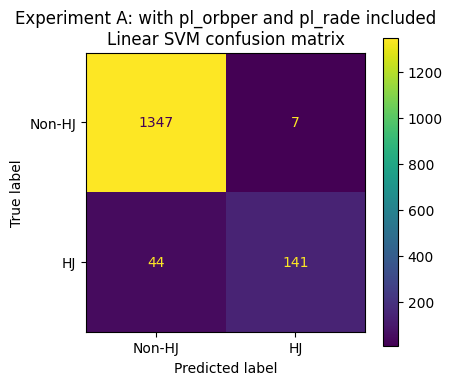

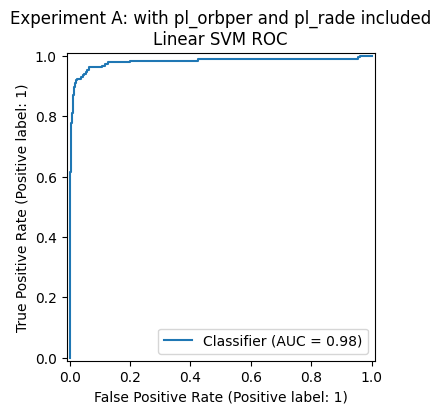

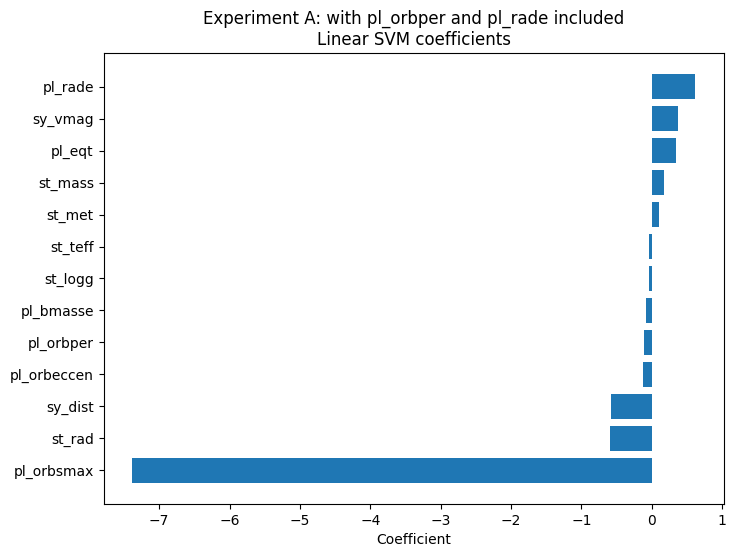

,feature,coefficient,abs_coefficient
4,pl_orbsmax,-7.389843,7.389843
1,pl_rade,0.619787,0.619787
7,st_rad,-0.591099,0.591099
11,sy_dist,-0.582762,0.582762
12,sy_vmag,0.378887,0.378887
5,pl_eqt,0.341301,0.341301
8,st_mass,0.174485,0.174485
3,pl_orbeccen,-0.128229,0.128229
0,pl_orbper,-0.111591,0.111591
9,st_met,0.097873,0.097873


Support vectors per class [Non-HJ, HJ]: [230 229]

RBF SVM results
----------------------------------------
Best params: {'clf__C': 10, 'clf__gamma': 'scale'}
Accuracy : 0.9779
F1       : 0.904
Precision: 0.9467
Recall   : 0.8649
ROC AUC  : 0.9931
              precision    recall  f1-score   support

           0      0.982     0.993     0.988      1354
           1      0.947     0.865     0.904       185

    accuracy                          0.978      1539
   macro avg      0.964     0.929     0.946      1539
weighted avg      0.978     0.978     0.977      1539



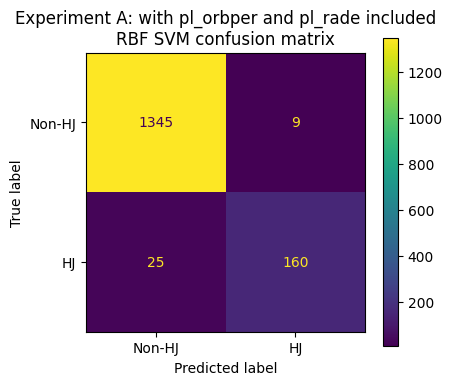

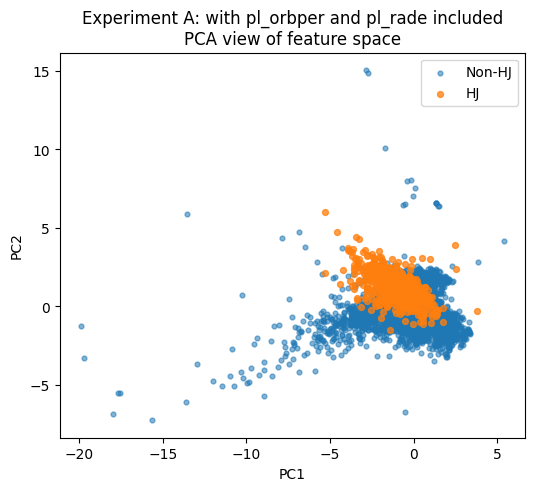

In [10]:
features_A = base_features.copy()

results_A = evaluate_svm_experiment(
    data,
    features_A,
    title="Experiment A: with pl_orbper and pl_rade included"
)

## Interpretation prompt for students

If `pl_orbper` and `pl_rade` have strong coefficients, that is expected, because they were used to define the target itself.

If `pl_orbsmax` is also strong, ask:

- why is semi-major axis closely related to orbital period?
- how does Kepler's law explain that?

# Experiment B — remove the defining features

Now we remove:

- `pl_orbper`
- `pl_rade`

This makes the task less trivial and more scientifically interesting.

The classifier must now rely on indirect information, such as:

- `pl_orbsmax`
- `pl_eqt`
- stellar properties
- other planetary characteristics

Experiment B: without pl_orbper and pl_rade
Train shape: (4614, 11) Test shape: (1539, 11)
Hot Jupiter fraction in train: 0.1201
Hot Jupiter fraction in test : 0.1202

Linear SVM results
----------------------------------------
Accuracy : 0.9038
F1       : 0.4519
Precision: 0.7176
Recall   : 0.3297
ROC AUC  : 0.8944
              precision    recall  f1-score   support

           0      0.915     0.982     0.947      1354
           1      0.718     0.330     0.452       185

    accuracy                          0.904      1539
   macro avg      0.816     0.656     0.700      1539
weighted avg      0.891     0.904     0.888      1539



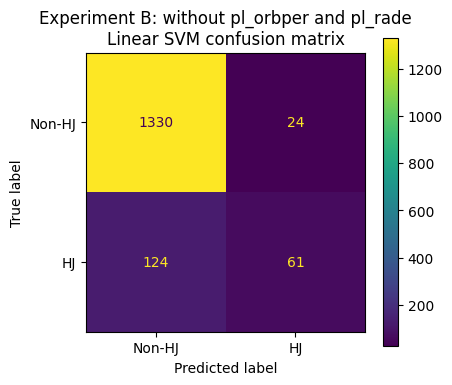

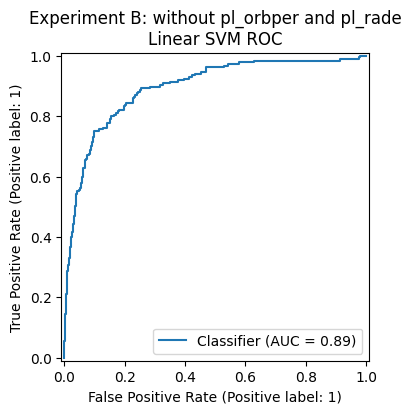

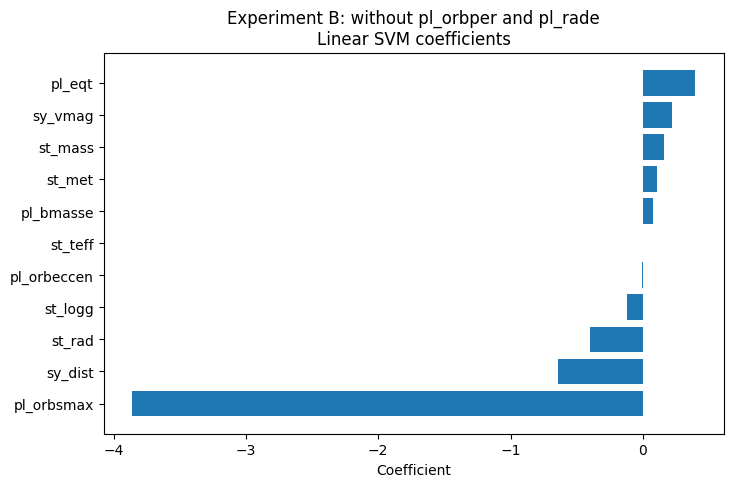

,feature,coefficient,abs_coefficient
2,pl_orbsmax,-3.862128,3.862128
9,sy_dist,-0.639607,0.639607
5,st_rad,-0.396973,0.396973
3,pl_eqt,0.396937,0.396937
10,sy_vmag,0.218428,0.218428
6,st_mass,0.162263,0.162263
8,st_logg,-0.118203,0.118203
7,st_met,0.108601,0.108601
0,pl_bmasse,0.075245,0.075245
1,pl_orbeccen,-0.009538,0.009538


Support vectors per class [Non-HJ, HJ]: [533 529]

RBF SVM results
----------------------------------------
Best params: {'clf__C': 10, 'clf__gamma': 0.1}
Accuracy : 0.9565
F1       : 0.7886
Precision: 0.947
Recall   : 0.6757
ROC AUC  : 0.9508
              precision    recall  f1-score   support

           0      0.957     0.995     0.976      1354
           1      0.947     0.676     0.789       185

    accuracy                          0.956      1539
   macro avg      0.952     0.835     0.882      1539
weighted avg      0.956     0.956     0.953      1539



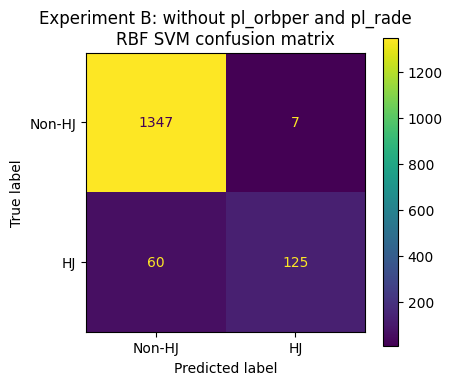

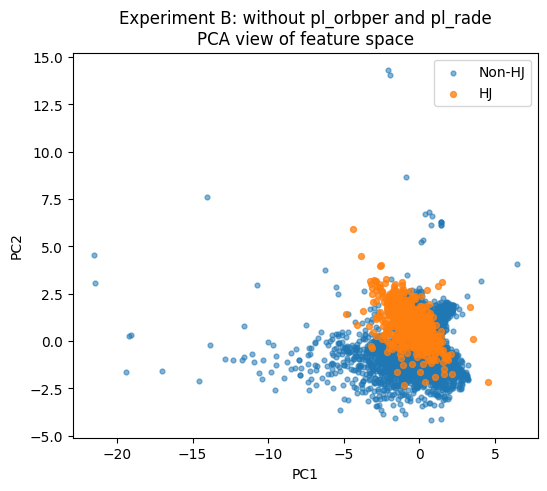

In [11]:
features_B = [f for f in base_features if f not in ["pl_orbper", "pl_rade"]]

results_B = evaluate_svm_experiment(
    data,
    features_B,
    title="Experiment B: without pl_orbper and pl_rade"
)

## Compare Experiment A and Experiment B

A strong drop in performance after removing `pl_orbper` and `pl_rade` would indicate that the original task was strongly driven by the target definition.

If the performance remains fairly good, that means other features retain predictive power through physical correlations.

In [12]:
comparison_df = pd.DataFrame([
    {
        "experiment": "A_with_definition_features",
        "n_features": len(results_A["feature_names"]),
        "linear_accuracy": results_A["linear_accuracy"],
        "linear_f1": results_A["linear_f1"],
        "linear_precision": results_A["linear_precision"],
        "linear_recall": results_A["linear_recall"],
        "linear_roc_auc": results_A["linear_roc_auc"],
        "rbf_accuracy": results_A["rbf_accuracy"],
        "rbf_f1": results_A["rbf_f1"],
        "rbf_precision": results_A["rbf_precision"],
        "rbf_recall": results_A["rbf_recall"],
        "rbf_roc_auc": results_A["rbf_roc_auc"],
        "best_rbf_params": str(results_A["best_rbf_params"]),
    },
    {
        "experiment": "B_without_definition_features",
        "n_features": len(results_B["feature_names"]),
        "linear_accuracy": results_B["linear_accuracy"],
        "linear_f1": results_B["linear_f1"],
        "linear_precision": results_B["linear_precision"],
        "linear_recall": results_B["linear_recall"],
        "linear_roc_auc": results_B["linear_roc_auc"],
        "rbf_accuracy": results_B["rbf_accuracy"],
        "rbf_f1": results_B["rbf_f1"],
        "rbf_precision": results_B["rbf_precision"],
        "rbf_recall": results_B["rbf_recall"],
        "rbf_roc_auc": results_B["rbf_roc_auc"],
        "best_rbf_params": str(results_B["best_rbf_params"]),
    }
]).round(3)

comparison_df

,experiment,n_features,linear_accuracy,linear_f1,linear_precision,linear_recall,linear_roc_auc,rbf_accuracy,rbf_f1,rbf_precision,rbf_recall,rbf_roc_auc,best_rbf_params
0,A_with_definition_features,13,0.967,0.847,0.953,0.762,0.979,0.978,0.904,0.947,0.865,0.993,"{'clf__C': 10, 'clf__gamma': 'scale'}"
1,B_without_definition_features,11,0.904,0.452,0.718,0.330,0.894,0.956,0.789,0.947,0.676,0.951,"{'clf__C': 10, 'clf__gamma': 0.1}"


# Optional extension — inspect borderline cases

Support vectors are the points closest to the boundary. They are especially interesting because they reveal which planets are hardest to classify.

In [13]:
# Rebuild a linear-kernel SVC on Experiment B for explicit support vectors
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

X_B = data[features_B]
y_B = data[target]

mask = y_B.notna()
X_B = X_B.loc[mask]
y_B = y_B.loc[mask]

X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(
    X_B, y_B, test_size=0.25, random_state=42, stratify=y_B
)

svc_support = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel="linear", C=1.0))
])

svc_support.fit(X_train_B, y_train_B)
sv_idx = svc_support.named_steps["clf"].support_

support_examples = X_train_B.iloc[sv_idx].copy()
support_examples["hot_jupiter"] = y_train_B.iloc[sv_idx].values
support_examples = support_examples.head(20)

support_examples

,pl_bmasse,pl_orbeccen,pl_orbsmax,pl_eqt,st_teff,st_rad,st_mass,st_met,st_logg,sy_dist,sy_vmag,hot_jupiter
5635,1.080000,0.000,0.06868,1211.00,6302.0,1.3500,1.2200,0.020,4.260,478.6470,12.208000,0
5110,2034.101805,0.597,0.16000,1221.39,7130.0,2.0200,1.5900,0.000,3.946,328.4750,9.867000,0
2429,8.100000,NaN,0.04900,955.00,5151.0,0.8600,0.8700,0.170,4.400,169.4220,11.632000,0
1703,3400.763955,0.370,NaN,NaN,6412.0,1.4160,1.3300,0.120,4.160,127.7740,8.720000,0
3644,41.800000,0.000,0.04580,934.50,4987.0,0.8268,0.8712,0.305,4.541,122.0660,11.559000,0
5057,12.500000,0.164,0.07630,1360.00,6047.0,1.6620,1.1070,-0.070,4.100,79.4070,8.020001,0
1388,10.700000,0.000,0.02860,1554.00,5751.0,1.0710,1.0280,0.210,4.391,392.7390,11.946000,0
1126,0.285000,0.000,0.02356,1642.00,5586.0,0.9300,0.9400,0.010,4.470,371.0490,12.344000,0
4194,2.480000,NaN,0.02470,1203.00,4877.0,0.7700,0.8500,0.260,4.590,280.5180,13.847000,0
5811,2.450000,NaN,NaN,1160.00,5791.0,0.9500,0.9800,-0.050,4.470,176.0510,11.125000,0


# Student exercises

## Exercise 1
Change the Hot Jupiter definition. Try one of these:

- $P < 5$ days and $R_p > 8R_\oplus$
- $P < 10$ days and $M_p > 100M_\oplus$
- $P < 10$ days and low eccentricity

How do the coefficients and performance change?


In [17]:
exo = exo.copy()

exo["hot_jupiter_2"] = (
    (exo["pl_orbper"] < 5) &
    (exo["pl_rade"] > 8)
).astype(int)

exo["hot_jupiter_2"].value_counts(dropna=False)

hot_jupiter_2
0    5556
1     597
Name: count, dtype: int64

In [18]:
target = "hot_jupiter_2"

data = exo[["pl_name", "hostname", target] + base_features].copy()
print(data.shape)
data.head()

(6153, 16)


,pl_name,hostname,hot_jupiter_2,pl_orbper,pl_rade,pl_bmasse,pl_orbeccen,pl_orbsmax,pl_eqt,st_teff,st_rad,st_mass,st_met,st_logg,sy_dist,sy_vmag
0,Kepler-1167 b,Kepler-1167,0,1.003934,1.710000,3.570,0.0,0.01750,1419.0,4971.0,0.750,0.790,-0.05,4.600,820.905,16.0470
1,Kepler-1740 b,Kepler-1740,0,8.172400,3.323214,11.000,0.0,0.07790,858.0,5705.0,0.905,0.943,-0.06,4.499,1061.770,15.4540
2,Kepler-1581 b,Kepler-1581,0,6.283855,0.800000,0.437,0.0,0.06865,1108.0,6022.0,1.230,1.120,0.07,4.310,493.175,12.4420
3,Kepler-644 b,Kepler-644,0,3.173917,3.150000,10.100,0.0,0.04641,1655.0,6747.0,1.810,1.490,0.08,4.090,1318.050,14.0310
4,Kepler-1752 b,Kepler-1752,0,56.358501,4.540605,18.700,0.0,0.26980,419.0,5446.0,0.821,0.824,-0.20,4.525,962.888,16.0249


Experiment C: with a stricter hot Jupiter definition
Train shape: (4614, 11) Test shape: (1539, 11)
Hot Jupiter fraction in train: 0.0971
Hot Jupiter fraction in test : 0.0968

Linear SVM results
----------------------------------------
Accuracy : 0.9155
F1       : 0.3689
Precision: 0.6667
Recall   : 0.255
ROC AUC  : 0.926
              precision    recall  f1-score   support

           0      0.925     0.986     0.955      1390
           1      0.667     0.255     0.369       149

    accuracy                          0.916      1539
   macro avg      0.796     0.621     0.662      1539
weighted avg      0.900     0.916     0.898      1539



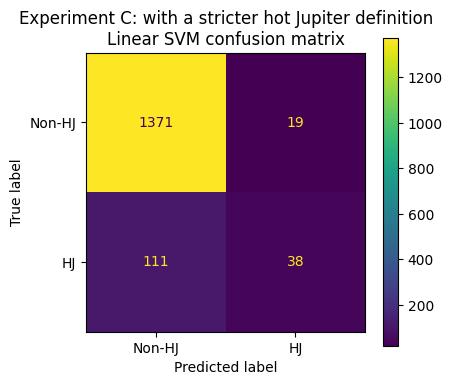

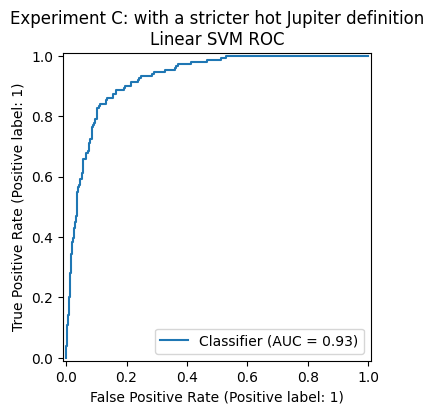

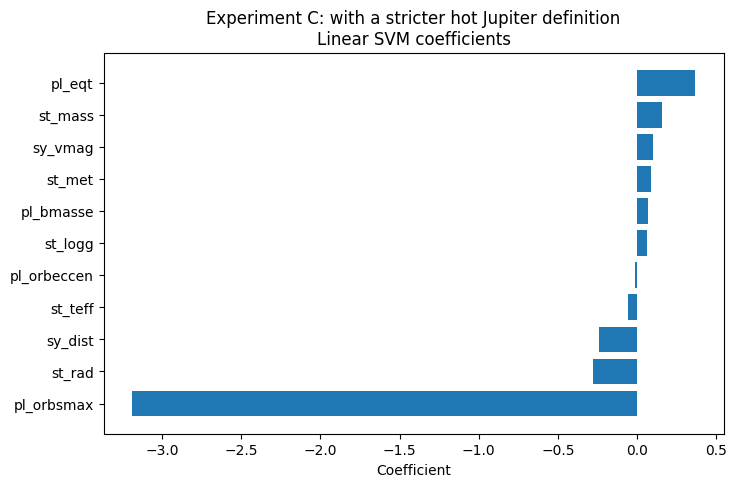

,feature,coefficient,abs_coefficient
2,pl_orbsmax,-3.192172,3.192172
3,pl_eqt,0.369067,0.369067
5,st_rad,-0.278221,0.278221
9,sy_dist,-0.241391,0.241391
6,st_mass,0.158870,0.158870
10,sy_vmag,0.098840,0.098840
7,st_met,0.088250,0.088250
0,pl_bmasse,0.071425,0.071425
8,st_logg,0.064554,0.064554
4,st_teff,-0.059604,0.059604


Support vectors per class [Non-HJ, HJ]: [452 447]

RBF SVM results
----------------------------------------
Best params: {'clf__C': 10, 'clf__gamma': 0.1}
Accuracy : 0.9578
F1       : 0.7547
Precision: 0.8621
Recall   : 0.6711
ROC AUC  : 0.9574
              precision    recall  f1-score   support

           0      0.966     0.988     0.977      1390
           1      0.862     0.671     0.755       149

    accuracy                          0.958      1539
   macro avg      0.914     0.830     0.866      1539
weighted avg      0.956     0.958     0.955      1539



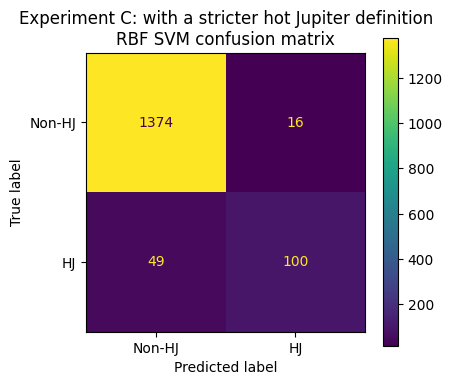

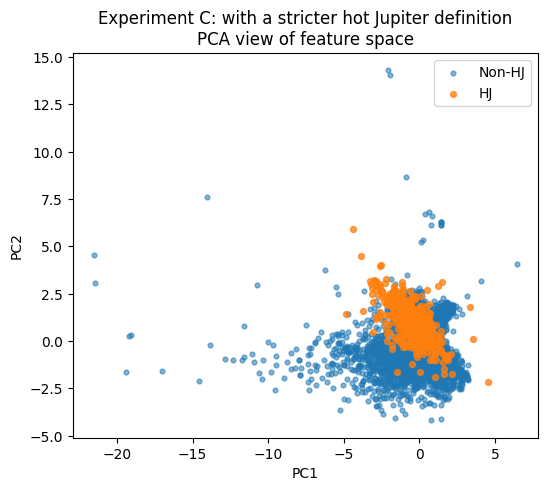

{'linear_model': Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                 ('scaler', StandardScaler()),
                 ('clf', LinearSVC(dual=False, max_iter=20000))]),
 'rbf_model': Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                 ('scaler', StandardScaler()), ('clf', SVC(C=10, gamma=0.1))]),
 'coef_df':         feature  coefficient  abs_coefficient
 2    pl_orbsmax    -3.192172         3.192172
 5        st_rad    -0.278221         0.278221
 9       sy_dist    -0.241391         0.241391
 4       st_teff    -0.059604         0.059604
 1   pl_orbeccen    -0.011620         0.011620
 8       st_logg     0.064554         0.064554
 0     pl_bmasse     0.071425         0.071425
 7        st_met     0.088250         0.088250
 10      sy_vmag     0.098840         0.098840
 6       st_mass     0.158870         0.158870
 3        pl_eqt     0.369067         0.369067,
 'best_rbf_params': {'clf__C': 10, 'clf__gamma': 0.1},
 'feature_names': 

In [19]:
evaluate_svm_experiment(
    data,
    features_B,
    title="Experiment C: with a stricter hot Jupiter definition"
)


## Exercise 2
Train on only stellar properties:

- `st_teff`
- `st_rad`
- `st_mass`
- `st_met`
- `st_logg`

Can stellar information alone predict Hot Jupiters at all?


Experiment D: only stellar features
Train shape: (4614, 5) Test shape: (1539, 5)
Hot Jupiter fraction in train: 0.1201
Hot Jupiter fraction in test : 0.1202

Linear SVM results
----------------------------------------
Accuracy : 0.8798
F1       : 0.0
Precision: 0.0
Recall   : 0.0
ROC AUC  : 0.7558
              precision    recall  f1-score   support

           0      0.880     1.000     0.936      1354
           1      0.000     0.000     0.000       185

    accuracy                          0.880      1539
   macro avg      0.440     0.500     0.468      1539
weighted avg      0.774     0.880     0.824      1539



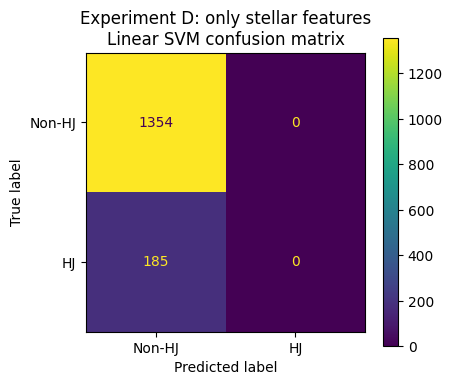

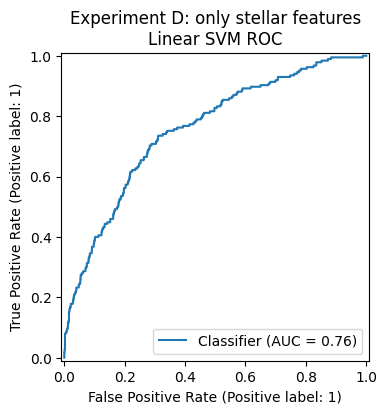

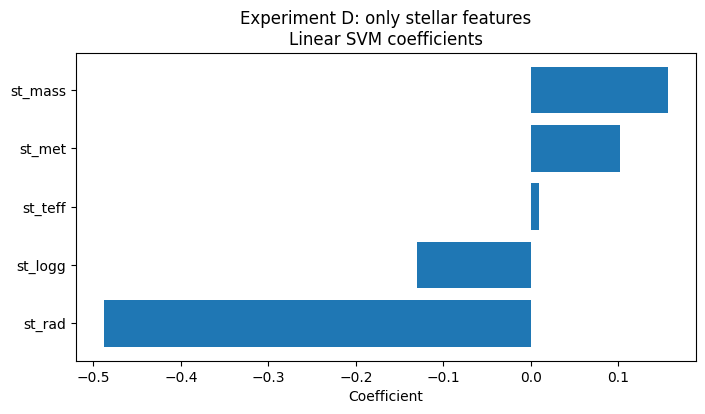

,feature,coefficient,abs_coefficient
1,st_rad,-0.487935,0.487935
2,st_mass,0.156285,0.156285
4,st_logg,-0.130458,0.130458
3,st_met,0.102355,0.102355
0,st_teff,0.009751,0.009751


Support vectors per class [Non-HJ, HJ]: [590 554]

RBF SVM results
----------------------------------------
Best params: {'clf__C': 10, 'clf__gamma': 1}
Accuracy : 0.8876
F1       : 0.21
Precision: 0.6765
Recall   : 0.1243
ROC AUC  : 0.6574
              precision    recall  f1-score   support

           0      0.892     0.992     0.939      1354
           1      0.676     0.124     0.210       185

    accuracy                          0.888      1539
   macro avg      0.784     0.558     0.575      1539
weighted avg      0.866     0.888     0.852      1539



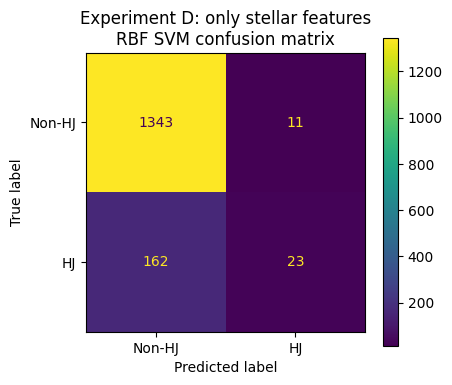

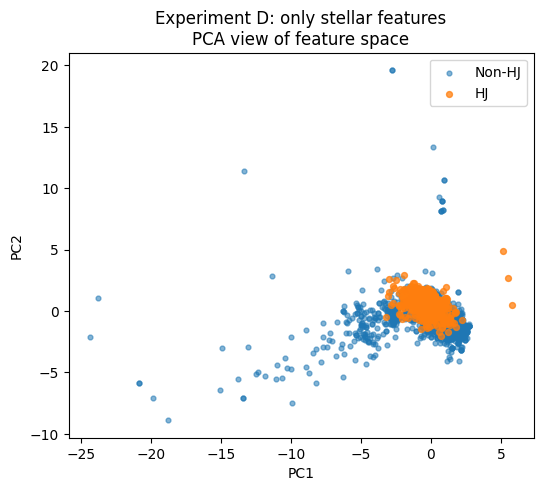

{'linear_model': Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                 ('scaler', StandardScaler()),
                 ('clf', LinearSVC(dual=False, max_iter=20000))]),
 'rbf_model': Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                 ('scaler', StandardScaler()), ('clf', SVC(C=10, gamma=1))]),
 'coef_df':    feature  coefficient  abs_coefficient
 1   st_rad    -0.487935         0.487935
 4  st_logg    -0.130458         0.130458
 0  st_teff     0.009751         0.009751
 3   st_met     0.102355         0.102355
 2  st_mass     0.156285         0.156285,
 'best_rbf_params': {'clf__C': 10, 'clf__gamma': 1},
 'feature_names': ['st_teff', 'st_rad', 'st_mass', 'st_met', 'st_logg'],
 'linear_accuracy': 0.8797920727745289,
 'linear_f1': 0.0,
 'linear_precision': 0.0,
 'linear_recall': 0.0,
 'linear_roc_auc': 0.7558245838157212,
 'rbf_accuracy': 0.8875893437296946,
 'rbf_f1': 0.2100456621004566,
 'rbf_precision': 0.6764705882352942,
 'rbf_re

In [15]:
stellar_features = base_features.copy()
stellar_features = [f for f in stellar_features if f.startswith("st_")]

evaluate_svm_experiment(
    data,
    stellar_features,
    title="Experiment D: only stellar features"
)


## Exercise 3
Compare Linear SVM and RBF SVM.

- Which performs better?
- Which is easier to interpret?
- When would you prefer each?



## Exercise 4
Discuss physically why:

- `pl_orbsmax`
- `pl_eqt`

might remain predictive even after removing `pl_orbper` and `pl_rade`.



## Exercise 5
Is this classification task discovering astrophysics, or partly recovering a human-made definition? Explain carefully.

# Teaching conclusion

This notebook shows two different but complementary lessons:

1. **Machine-learning lesson**  
   SVMs build separating hyperplanes, and their coefficients can often be interpreted physically.

2. **Scientific-method lesson**  
   A model can appear to perform very well simply because the input features overlap with the target definition. This is a form of **definition leakage**.

That is why comparing Experiment A and Experiment B is so instructive.